In [12]:
import pandas as pd
import numpy as np
import re
from collections import Counter

In [13]:
emails_df = pd.read_csv('../data/02_cleaned_emails_unlabelled_internal.csv')
emails_df.head()

,Date,From,To,Subject,X_From,X_To,Message,Entire-Message,DISC
0,"Fri, 4 May 2001 13:51:00 -0700 (PDT)",phillip.allen@enron.com,john.lavorato@enron.com,Re:,Phillip K Allen,John J Lavorato <John J Lavorato/ENRON@enronXg...,Traveling to have a business meeting takes the...,Re: Traveling to have a business meeting takes...,NaN
1,"Mon, 23 Oct 2000 06:13:00 -0700 (PDT)",phillip.allen@enron.com,randall.gay@enron.com,No Subject,Phillip K Allen,Randall L Gay,"Randy,\n Can you send me a schedule of the sal...","No Subject Randy,\n Can you send me a schedule...",NaN
2,"Mon, 16 Oct 2000 06:42:00 -0700 (PDT)",phillip.allen@enron.com,buck.buckner@honeywell.com,Re: FW: fixed forward or other Collar floor ga...,Phillip K Allen,"""Buckner, Buck"" <buck.buckner@honeywell.com> @...","Mr. Buckner,\n For delivered gas behind San Di...",Re: FW: fixed forward or other Collar floor ga...,NaN
3,"Fri, 13 Oct 2000 06:45:00 -0700 (PDT)",phillip.allen@enron.com,stagecoachmama@hotmail.com,No Subject,Phillip K Allen,stagecoachmama@hotmail.com,"Lucy,\n Here are the rentrolls:\n Open them an...","No Subject Lucy,\n Here are the rentrolls:\n O...",NaN
4,"Tue, 3 Oct 2000 09:13:00 -0700 (PDT)",phillip.allen@enron.com,bs_stone@yahoo.com,No Subject,Phillip K Allen,bs_stone@yahoo.com,"Brenda,\nPlease use the second check as the Oc...","No Subject Brenda,\nPlease use the second chec...",NaN


In [14]:
emails_df.columns

Index(['Date', 'From', 'To', 'Subject', 'X_From', 'X_To', 'Message',
       'Entire-Message', 'DISC'],
      dtype='object')

In [15]:
emails_df_msg_label = emails_df.drop(columns=['X_From', 'X_To', 'Date', 'From', 'To', 'Subject', 'Message'])
emails_df_msg_label.head()

,Entire-Message,DISC
0,Re: Traveling to have a business meeting takes...,NaN
1,"No Subject Randy,\n Can you send me a schedule...",NaN
2,Re: FW: fixed forward or other Collar floor ga...,NaN
3,"No Subject Lucy,\n Here are the rentrolls:\n O...",NaN
4,"No Subject Brenda,\nPlease use the second chec...",NaN


In [16]:
emails_df_msg_label.to_csv('../data/03_cleaned_email_msg.csv', index=False)

## Use Rule-Based Keyword Matching to label sample emails

In [17]:
emails_df_rule_based_samples = emails_df_msg_label.sample(5000, random_state=32).copy()
rule_based_ids = emails_df_rule_based_samples.index.tolist()
print(rule_based_ids)

[9632, 14004, 36341, 61467, 44636, 24186, 36369, 37278, 18659, 1398, 14419, 13491, 22505, 11168, 19919, 13393, 18292, 40683, 7572, 21040, 61677, 29340, 5153, 34953, 16801, 61812, 30233, 46763, 9644, 62794, 29113, 5347, 40886, 7006, 53409, 64128, 49432, 35929, 58604, 25123, 37636, 1508, 49409, 50807, 34779, 24000, 6483, 53779, 39550, 59438, 50583, 60494, 62924, 23267, 36803, 60246, 41108, 25429, 10348, 19077, 43388, 17236, 57125, 7139, 60791, 23852, 27430, 14264, 2834, 4125, 41697, 18726, 14965, 19241, 22457, 42818, 3853, 10562, 36461, 38614, 3426, 32654, 23607, 32981, 16552, 27861, 26092, 1233, 654, 29675, 48851, 35372, 19757, 13772, 24511, 24110, 9999, 19166, 25107, 17722, 7609, 12137, 46433, 31272, 3918, 25471, 6877, 50972, 62582, 16890, 59298, 20023, 46425, 31611, 26328, 51445, 1884, 29760, 45639, 35904, 52568, 8786, 122, 9724, 26159, 19080, 21611, 44908, 3790, 41219, 58352, 24382, 21755, 11199, 58262, 23472, 3692, 10684, 7284, 58275, 53131, 19469, 63309, 21280, 3077, 44274, 63370, 

In [18]:
# lowercasing and remove punctuation
PUNC_PATTERN = re.compile(r'[^\w\s]')

def preprocess_text_for_rule_based(text):
    if not isinstance(text, str):
        return ''


    text = PUNC_PATTERN.sub('', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip().lower()
    return text

emails_df_rule_based_samples['Entire-Message'] = emails_df_rule_based_samples['Entire-Message'].apply(preprocess_text_for_rule_based)
emails_df_rule_based_samples.head()

,Entire-Message,DISC
9632,letter to senators bear with me i want to work...,NaN
14004,mid year prc meeting i would like to have our ...,NaN
36341,notice to all enrononline traders before you b...,NaN
61467,nissan to produce 80 percent ulev cars by 2003...,NaN
44636,re revised cutter oil contract regarding artic...,NaN


In [19]:
DISC_KEYWORDS = {
    'D' : ["deadline", "urgent", "now", "action", "priority", "resolve", "results",
        "decision", "goal", "challenge", "do it", "fast", "push", "lead", "firm", "pressure", "action required",
        "quickly", "at all costs", "make it happen", "efficiently", "asap"
        "take the lead", "take action", "do it now", "get this done", "make sure",
        "ensure", "enforce", "absolutely", "direct", "right now", "immediately",
        "speed", "I want", "I said", "must",  "put questions to rest", "your fault",
        "your mistake", "your apologies", "your bad", "your error", "your oversight",
        "your slip", "your blunder", "your carelessness", "your inattention",
        "your neglect", "your omission", "your oversight", "I guarantee",
        "enough is enough", " you need to"],
    'I' : ["excited", "great job", "lets", "share", "appreciate",
        "celebrate", "fun", "engage", "collaborate", "believe",
          "nice to hear", "amazing", "awesome", "fantastic", "get a hold of me",
          "discuss", "chat", "jokes", "laugh", "smile", "happy", "good news", "favorite",
          "favourite", "celebrate", "congratulations", "kudos", "celebration", "party",
          "playing", "exciting", "thrilling", "enjoy", "game"],
    'S' : ["kindly", "let me know", "available", "cooperate", "help", "understand",
        "follow up", "consistent", "appreciate your help", "thanks again",
        "dont worry", "help in any way I can", "let me know", "comfortable",
        "sorry for not responding", "thank you so much", "my fault", "my mistake",
        "my apologies", "my bad", "my error", "my oversight", "my slip", "my blunder",
        "my carelessness", "my inattention", "my neglect", "my omission", "my oversight",
        "sorry", "apologize for", "agree"],
    'C' : ["details", "data", "report", "analyze", "summary", "document", "proof",
        "schedule", "spreadsheet", "accuracy", "format", "process", "standards", "analysis",
        "compliance", "audit", "method", "evidence", "confirm", "structured", "sources",
        "review", "check", "validate", "verify", "validate", "as per", "according to",
        "in accordance with", "consistent with", "comply with", "follow", "procedure",
        "guideline", "manual", "policy", "regulation", "rule", "standard", "statute",
        "requirement", "specification", "protocol", "principle", "reconcile", "cross-check",
        "cross-reference", "corroborate", "substantiate", "authenticate", "confirm", "justify",
        "hindsight", "forethought", "foresight", "insight", "formula", "unjustified",
        "unsubstantiated", "unverified", "unvalidated", "unconfirmed", "unjust", "unreasonable",
        "looking into", "investigate", "examine", "probe", "scrutinize", "inspect", "identified",
        "final execution", "implementation", "calculation", "agreement", "calibrate"]
}

In [20]:
# def match_disc_label(msg):
#     disc_labels = set()
#     for label, keywords in DISC_KEYWORDS.items():
#         for word in keywords:
#             if word in msg:
#                 disc_labels.add(label)

#     return disc_labels

def match_disc_label(msg, max_freq=2):
    labels_freq = {'D': 0, 'I': 0, 'S': 0, 'C': 0}
    for label, keywords in DISC_KEYWORDS.items():
        for word in keywords:
            if word in msg:
                labels_freq[label] += 1
    # print(labels_freq)

    filter_labels = {label: freq for label, freq in labels_freq.items() if freq > 0}
    if not filter_labels:
        return ()

    # sorted_labels_freq = sorted(filter_labels.items(), key=lambda x: (-x[1], x[0]))
    sorted_labels_freq = sorted(filter_labels.items(), key=lambda x: x[0])
    top_labels = [label for label, freq in sorted_labels_freq[:max_freq]]
    return tuple(top_labels)

emails_df_rule_based_samples['DISC_rule_based'] = emails_df_rule_based_samples['Entire-Message'].apply(match_disc_label)

print(emails_df_rule_based_samples.head(5))

label_count = emails_df_rule_based_samples['DISC_rule_based'].value_counts()
print(label_count)


                                          Entire-Message  DISC DISC_rule_based
9632   letter to senators bear with me i want to work...   NaN            (D,)
14004  mid year prc meeting i would like to have our ...   NaN          (C, D)
36341  notice to all enrononline traders before you b...   NaN          (C, I)
61467  nissan to produce 80 percent ulev cars by 2003...   NaN          (C, D)
44636  re revised cutter oil contract regarding artic...   NaN          (C, S)
DISC_rule_based
(C, D)    2063
()         643
(C,)       511
(C, I)     320
(D, I)     297
(D, S)     270
(D,)       269
(C, S)     247
(I,)       219
(S,)       108
(I, S)      53
Name: count, dtype: int64


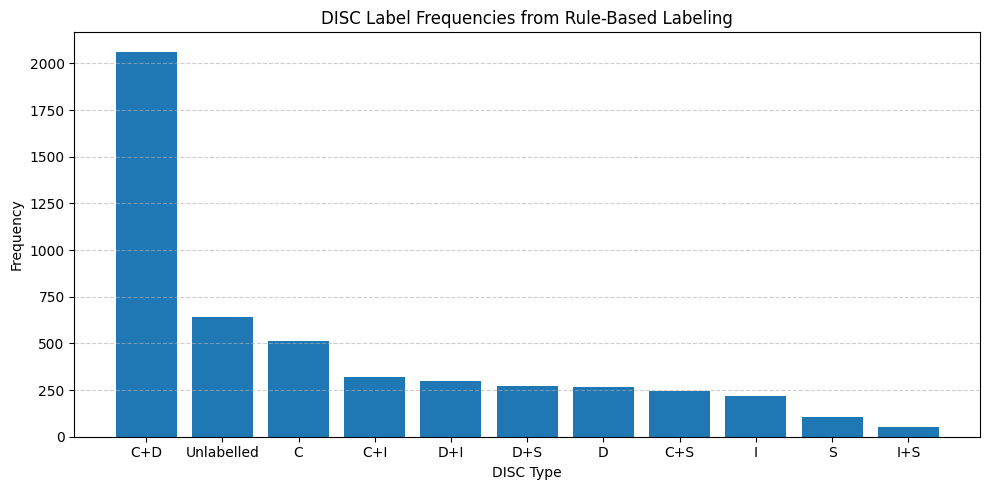

<Figure size 640x480 with 0 Axes>

In [21]:
import matplotlib.pyplot as plt

x_labels = label_count.index.map(lambda x: 'Unlabelled' if isinstance(x, tuple) and len(x) == 0
                                 else '+'.join(x) if isinstance(x, tuple)
                                else str(x))


plt.figure(figsize=(10, 5))
plt.bar(x_labels, label_count.values)
plt.title("DISC Label Frequencies from Rule-Based Labeling")
plt.xlabel("DISC Type")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

plt.savefig('../figures/03_rule_based_disc_label_freq.pnggit add .'
'')

In [22]:
# emails_df_rule_based_none = emails_df_rule_based[emails_df_rule_based['DISC_rule_based'].apply(lambda x: len(x) == 0)]
# print(emails_df_rule_based_none['Entire-Message'])

# emails_df_rule_based_none.to_csv('../data/msg_without_labels.csv', index=False)
# print(emails_df_rule_based_none.value_counts())